# Spotify Lab: Vectors, Inner Products, and Similar Songs

**Name(s):** Diego McGrath, Aeden Rask

You are a new data engineer at Spotify.

When a listener asks for songs with similar content, we want to query the library of music and select appropriate recommendations. 

Every song is represented as a vector, and we are using a **vector database**: Each song is encoded as a vector of word counts. So if "love" appears 12 times in the song, the "love" coordinate is $x_{\text{love}}=12$. If Metallica writes songs about topics that are more similar to Black Sabbath than to Josh Groban, then the vector representations of their songs will have more similar profiles, and we should suggest Black Sabbath over Josh Groban. This approach is fundamental to technologies like LLMs or facial recognition, which store documents and faces as vectors and conducts fast look-ups using the kinds of math we'll look at in this lab.

The main data, `song_vectors.csv.gz`, include:

- `track_id`, `song_id`, `artist_id`: Internal unique track identifiers
- `artist_name`, `song_title`, `release`: Artist, song, album
- `release_year`, `duration`: `
- `artist_familiarity`, `artist_hotttnesss`: Measures of ubiquity, popularity
- `genre`, `top_tags`: Information about the song type
- `n_words`, `nnz_words`, `l2_norm`: Number of total words in the song, number of non-zero word coordinates (i.e. number of unique words), and the word counts squared/summed/square-rooted.
- `is_test`: Train-test split identification
- 800 columns of word counts

The `top_40_songs_by_genre.csv` file contains the top 40 songs by genre -- rock, metal, pop, punk, country, r&b/soul, folk, hip hop, electronic, blues, jazz, reggae, latin, classical -- by "hotttness". We'll use these songs to benchmark.

The `vocabulary.csv` file includes the 800 words that form the vector space in which the songs are modeled.

Each song becomes a vector of lyric-word counts, and then we use vector operations to quantify "similarity".

The big goal of this lab is simple:

**Vectors and inner products and vector length are the core tools of modern retrieval systems.**

## Setup

We will use:

- `./data/song_vectors.csv.gz`: one row per song
- `./data/vocabulary.csv`: the word columns used in the song vectors

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


songs = pd.read_csv( "./data/song_vectors.csv.gz" )
vocab = pd.read_csv( "./data/vocabulary.csv" )
top_40 = pd.read_csv("./data/top_40_songs_by_genre.csv")

word_cols = vocab["word"].tolist() # Song count matrix
meta_cols = songs.columns.drop(word_cols).tolist() # Information about tracks

print('Number of songs, number of words:', songs.shape)
print( 'Song metadata fields:', meta_cols[:8])

Number of songs, number of words: (8000, 816)
Song metadata fields: ['track_id', 'song_id', 'artist_id', 'artist_name', 'song_title', 'release', 'release_year', 'duration']


In [12]:
songs[meta_cols].head()

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test
0,TRAAPIV128F1493132,SOJHKYL12A6D4FA0AC,AR56P361187B9AC4DB,Gary Moore,What Are We Here For,Dark Days In Paradise,1997,345.93914,0.761362,0.467111,blues,blues; classic rock; rock; hard rock; blues rock,218,80,37.376463,0
1,TRAAWOR128F92DF3C8,SOBJYXZ12A8AE45FF1,ARY80281187FB3E380,Sandi Thom,Wounded Hearts,The Pink & The Lily,2008,205.21751,0.655359,0.405031,blues,blues,287,103,39.698866,0
2,TRABNZS128F932C6E8,SOCOZZE12A813568F7,AROWOZ41187FB5B535,G. Love & Special Sauce,Willow Tree,Yeah_ It's That Easy,1997,206.57587,0.717235,0.548694,blues,blues; chill; alternative; rock; jazz,211,64,33.090784,0
3,TRABOIH128F9300B06,SOHYOTB12AF72AA1D7,AR94ZOI1187FB46BDA,Willie Dixon,That's My Baby,Very Best Of The Blues,1989,208.90077,0.579533,0.429834,blues,delta blues; BLUEZZZ; blues; freedom; Willie D...,164,76,27.477263,0
4,TRABYAR128F931B1A4,SOVKUOE12A58A8066E,AR7BMMV1187FB5B2D7,Robben Ford,Something For The Pain,Blue Moon,2002,298.37016,0.604820,0.383877,blues,blues; Robben Ford; vinnie colaiuta; jimmy earl,187,75,27.604347,0


## Part 1: Similarity Measures for Song Vectors

The word-count columns are coordinates. That means each song is a vector in a high-dimensional space.

We will work with the song-by-word matrix $X$, where each row is one song vector.

In [13]:
X = songs[word_cols].to_numpy(dtype=float)

query_idx = 0 # Let's query the first song
query = X[query_idx]

print( 'Track metadata: \n')
print(songs.loc[query_idx, meta_cols])

print( 'Track word counts: \n')
print( query )

Track metadata: 

track_id                                            TRAAPIV128F1493132
song_id                                             SOJHKYL12A6D4FA0AC
artist_id                                           AR56P361187B9AC4DB
artist_name                                                 Gary Moore
song_title                                        What Are We Here For
release                                          Dark Days In Paradise
release_year                                                      1997
duration                                                     345.93914
artist_familiarity                                            0.761362
artist_hotttnesss                                             0.467111
genre                                                            blues
top_tags              blues; classic rock; rock; hard rock; blues rock
n_words                                                            218
nnz_words                                                  

In [14]:
# Let's see the counts for nonzero words

nonzero = np.flatnonzero(query)

pd.DataFrame({
    "word": np.array(word_cols)[nonzero],
    "count": query[nonzero].astype(int),
}).sort_values("count", ascending=False).head(15)

,word,count
62,we,27
4,are,10
17,for,9
37,of,7
26,it,6
63,what,6
21,here,6
20,have,6
41,our,5
54,through,5


## Step 1: Dot Product

The dot product is our first similarity score:

$$
x \cdot y = \sum_{j=1}^m x_j y_j
$$

It gets large when two songs align count mass on the same words. 

It also tends to go up for longer songs or songs with larger total counts, which is a choice we'll have to think about.

In [15]:
# Compute the dot product between every song vector and the query vector.
dot_scores = X @ query

dot_results = songs[meta_cols].copy()
dot_results["dot"] = dot_scores
dot_results.sort_values("dot", ascending=False).head(10)

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test,dot
1582,TRFSCLD12903CD213F,SOENGNL12AB018E1BD,AR4L4WQ1187FB51996,The Prodigy,We Gonna Rock,What Evil Lurks,1991,282.30485,0.638614,0.601436,electronic,Rave; big beat; jungle; electronic; techno,312,10,141.703917,0,2136.0
6290,TRFUJVJ128F426F2A2,SOONCPO12AF72A1986,AR8W8P31187B9A4063,Lauryn Hill,Interlude 5,MTV Unplugged No. 2.0,2002,734.48444,0.697206,0.580125,r&b/soul,ms hill; the realness; The Truth; true; rnb,1903,409,215.044182,0,2115.0
5601,TRCETEN128F42AD6D0,SOXSRBF12D021B1340,AR4KTMS1187B9B4873,Bowling For Soup,Here We Go,Goes To The Movies,2004,188.36853,0.790406,0.561934,punk,pop punk; The Good Stuff; Bowling For Soup; pr...,374,92,98.863542,0,1939.0
1930,TRWAMJL128F92D124B,SOUSJHY12A8C1457F0,ARQ85IK11C8A415C6A,Ladyhawke,Crazy World,Ladyhawke,2008,214.93506,0.692569,0.554471,electronic,electropop; indie; female vocalists; electroni...,340,58,74.229374,0,1680.0
6997,TRLDRZN128F4288F63,SOBLSVV12A8C13E4F8,ARLUAK21187B9B785A,Ziggy Marley And The Melody Makers,We Propose,Conscious Party,0,274.46812,0.750480,0.538491,reggae,reggae; marijuana; Reg-i-die,297,97,58.180753,0,1656.0
3053,TRTCOWO128F930C444,SONWWDY12A6D4F7FB1,ARIHE7O1187FB47DED,The Streets,Weak Become Heroes,Summer Sessions,0,494.54975,0.772909,0.527872,hip hop,british; Hip-Hop; garage; 00s; hip hop,754,262,96.337947,0,1654.0
2971,TRPDBLM128E0792367,SOZRPOY12A8C1455F5,ARTDQRC1187FB4EFD4,Black Eyed Peas,Communication,Behind The Front,1998,344.00608,0.845602,1.005942,hip hop,Hip-Hop; funk; dance; communication; heisse sc...,592,173,80.068720,0,1615.0
2874,TRKRVKD128F9327008,SOXKVEZ12AB01821F5,ARX94AN1187FB4B54B,Hollywood Undead,Undead,Desperate Measures,2008,288.07791,0.703476,0.576626,hip hop,rapcore; hollywood undead; rap metal; rock; un...,831,222,97.082439,0,1476.0
0,TRAAPIV128F1493132,SOJHKYL12A6D4FA0AC,AR56P361187B9AC4DB,Gary Moore,What Are We Here For,Dark Days In Paradise,1997,345.93914,0.761362,0.467111,blues,blues; classic rock; rock; hard rock; blues rock,218,80,37.376463,0,1397.0
5840,TRMGOLR128F933A7DB,SOYDERO12A6D4F72BC,ARZWK2R1187B98F09F,Rise Against,Survive,The Sufferer & The Witness,2006,221.46567,0.847082,0.625080,punk,punk rock; melodic hardcore; punk; rock; Rise ...,324,85,56.169387,0,1383.0


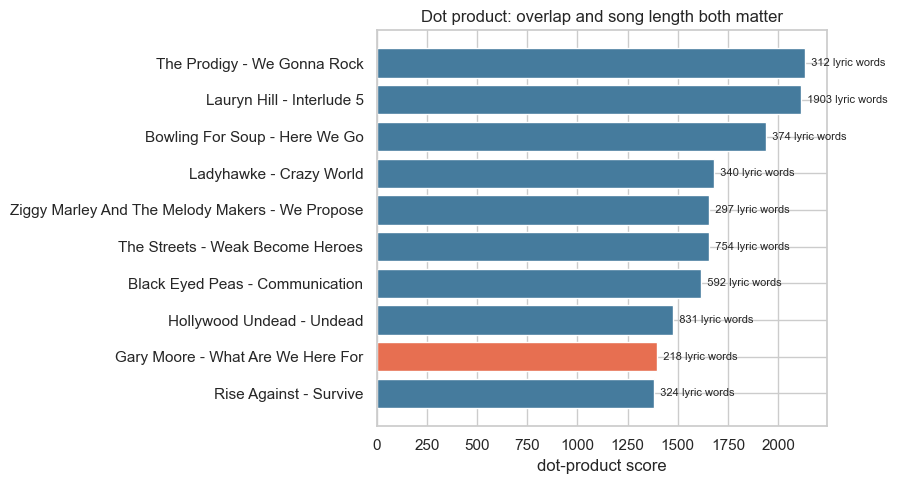

In [16]:
# Visual check: long songs can receive larger dot products.
top_dot = dot_results.sort_values("dot", ascending=False).head(10).copy()
top_dot["label"] = (
    top_dot["artist_name"].fillna("") + " - " + top_dot["song_title"].fillna("")
)
colors = ["#e76f51" if index == query_idx else "#457b9d" for index in top_dot.index]
plt.figure(figsize=(9, 5))
plt.barh(top_dot["label"], top_dot["dot"], color=colors)
for position, words in enumerate(top_dot["n_words"]):
    plt.text(top_dot["dot"].iloc[position], position, f"  {words:.0f} lyric words", va="center", fontsize=8)
plt.gca().invert_yaxis()
plt.xlabel("dot-product score")
plt.title("Dot product: overlap and song length both matter")
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-warning">

Look at the top matches. Do they seem similar because they use similar words, because they are genuinely similar songs, or because the dot product is partly rewarding song size?

Adapt the above code chunks to find the top three **non-self** matches for all of the Top 40 songs by genre using the raw inner product. Before sorting, set the query song's score to `-np.inf`. Save your results as additional columns in "./data/top_40_songs_by_genre_results.csv".

</div>

They seem similar because they use similar words primarily, but Lauryn Hill's Interlude 5 seems to be a good match mostly because it is such a long song that has so many words that can easily match, since it does not match the blues genre. Also, the top 3 are not even in the same genre or similar genres at all, which further makes me think that it is because they have similar words. 

In [40]:
results = top_40.copy()

top1_artist = []
top1_song = []

top2_artist = []
top2_song = []

top3_artist = []
top3_song = []

for track_id in top_40["track_id"]:
    
    query_idx = songs.index[songs["track_id"] == track_id][0]
    query = X[query_idx]
    
    dot_scores = X @ query
    dot_scores[query_idx] = -np.inf
    
    top_indices = np.argsort(dot_scores)[-3:][::-1]
    
    top1_artist.append(songs.loc[top_indices[0], "artist_name"])
    top1_song.append(songs.loc[top_indices[0], "song_title"])
    
    top2_artist.append(songs.loc[top_indices[1], "artist_name"])
    top2_song.append(songs.loc[top_indices[1], "song_title"])
    
    top3_artist.append(songs.loc[top_indices[2], "artist_name"])
    top3_song.append(songs.loc[top_indices[2], "song_title"])

results["match_1_artist"] = top1_artist
results["match_1_song"] = top1_song

results["match_2_artist"] = top2_artist
results["match_2_song"] = top2_song

results["match_3_artist"] = top3_artist
results["match_3_song"] = top3_song

results.head()

,track_id,song_id,artist_id,artist_name,song_title,genre,match_1_artist,match_1_song,match_2_artist,match_2_song,match_3_artist,match_3_song
0,TRVYEUW128F148C08D,SOFCCWD12AF72A6BC0,ARXPPEY1187FB51DF4,Michael Jackson,All The Things You Are,blues,Lauryn Hill,Interlude 5,Twista,I'm A Winner (Amended Album Version),Katy Perry,Hot N Cold (Innerpartysystem Main)
1,TRCXKPC128F92FD04C,SOEFNXT12AB017E829,ARZENOX1187B98A645,John Mayer,Vultures,blues,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,Lauryn Hill,Interlude 5,R. Kelly,I Mean (I Don't Mean It)
2,TRMMALW128F92FD049,SOVUCRS12A58A7D207,ARZENOX1187B98A645,John Mayer,Out Of My Mind,blues,Lauryn Hill,Interlude 5,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,Twista,I'm A Winner (Amended Album Version)
3,TRJWAJC128F9327C4F,SORMDVX12AB01816AA,ARLMXEA1187B9A7D04,R. Kelly,Hump Bounce,blues,Lauryn Hill,Interlude 5,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,Erykah Badu,I Want You
4,TRPEBTH128F9327C4D,SOYTJAC12AF729F49D,ARLMXEA1187B9A7D04,R. Kelly,Intro - The Sermon,blues,Lauryn Hill,Interlude 5,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,Twista,I'm A Winner (Amended Album Version)


In [41]:
results.to_csv("./data/top_40_songs_by_genre_results.csv", index=False)

## Step 2: Centering and Covariance

Now we subtract each vector's own mean. This changes the question from "Do these songs use many of the same words?" to something closer to "Do these songs rise above and below their own average on the same words?"

In [30]:
query_centered = query - query.mean()
X_centered = X - X.mean(axis=1, keepdims=True)

centered_dot_scores = X_centered @ query_centered
covariance_scores = centered_dot_scores / X.shape[1]

cov_results = songs[meta_cols].copy()
cov_results["centered_dot"] = centered_dot_scores
cov_results["covariance"] = covariance_scores
cov_results.sort_values("covariance", ascending=False).head(10)

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test,centered_dot,covariance
6290,TRFUJVJ128F426F2A2,SOONCPO12AF72A1986,AR8W8P31187B9A4063,Lauryn Hill,Interlude 5,MTV Unplugged No. 2.0,2002,734.48444,0.697206,0.580125,r&b/soul,ms hill; the realness; The Truth; true; rnb,1903,409,215.044182,0,4783.12000,5.978900
2691,TRDPGXU128F9339C2A,SOELYON12AB01876A3,ARLHO5Z1187FB4C861,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,Paul's Boutique (20th Anniversary Remastered E...,0,105.56036,0.853125,0.591628,hip hop,hip hop; leapsandbounds CDCollection,1746,505,153.652205,0,4767.60375,5.959505
2659,TRCHZXW128E079288A,SOMEJDK12D0219BB71,ARTH9041187FB43E1F,Eminem,8 Mile,8 Mile,2002,359.39220,0.886184,0.852677,hip hop,rap; Hip-Hop; Eminem; Soundtrack; hip hop,1141,328,132.992481,0,4094.49625,5.118120
3029,TRRSNPA128F148C45E,SOIUOEW12A67021D3D,AR8RXRI1187FB4104B,The Roots,Mellow My Man,From The Ground Up,0,288.31302,0.862795,0.600282,hip hop,Hip-Hop; jazzy; the roots; rap; hip hop,886,270,117.358425,0,3734.87625,4.668595
2763,TRGLNKG128F9307689,SOFVLYU12AB017F502,ARTH9041187FB43E1F,Eminem,My Darling,Relapse [Deluxe],2009,320.49587,0.871011,0.879237,hip hop,rap; detroit; Hip-Hop; Horrorcore; MOONH8SUN,1055,293,140.089257,0,3704.24125,4.630302
5245,TRLTYLK128F92FE6FF,SOWVIEO12AB0182D10,AR03BDP1187FB5B324,Britney Spears,Radar,Radar,2007,353.33179,0.947328,0.607257,pop,pop; dance; Britney Spears; female vocalists; ...,500,96,116.614750,0,3635.32375,4.544155
3125,TRWSYHO128F4282346,SOKHOQG12A8C13EBF2,ARSE5NP1187B9B98AB,Twista,I'm A Winner (Amended Album Version),The Day After,2005,260.23138,0.889614,0.593808,hip hop,rap; Hip-Hop; winner in bed twista,1253,166,218.622963,0,3594.83250,4.493541
2815,TRISBQQ128F93217A2,SOSKAYL12AB01884DE,ARPXABO1187FB4D15F,2Pac,Strictly 4 My N.I.G.G.A.Z.,Strictly 4 My N.I.G.G.A.Z.,0,355.47383,0.873187,0.517256,hip hop,Hip-Hop; hardcore rap; west coast hip-hop; lea...,921,288,104.316825,0,3565.21250,4.456516
2627,TRBEBJO128C719646B,SORXHBR12AF72A5DA5,ARCBD0U1187FB466EF,Nelly,Splurge,Nellyville,2002,309.49832,0.912369,0.787995,hip hop,Hip-Hop; rap; hip hop; rnb; 00s,911,225,131.289756,0,3550.71125,4.438389
6492,TROIJDA128F9341E70,SOCUXGX12A8C13B78C,ARLMXEA1187B9A7D04,R. Kelly,I Mean (I Don't Mean It),TP-2.com,2000,205.00853,0.811092,0.783843,r&b/soul,soul; rnb; english lyrics; SDZ,701,190,135.443715,0,3531.92375,4.414905


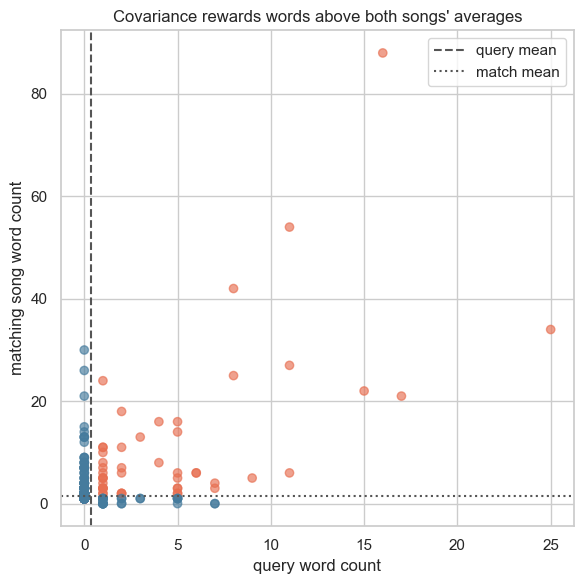

In [27]:
# Visual check: centering moves each song's average word count to zero.
comparison_idx = np.argsort(covariance_scores)[-2]
comparison = X[comparison_idx]
used_words = (query > 0) | (comparison > 0)
both_above_average = (query > query.mean()) & (comparison > comparison.mean())
plt.figure(figsize=(6, 6))
plt.scatter(query[used_words], comparison[used_words],
            c=np.where(both_above_average[used_words], "#e76f51", "#457b9d"), alpha=0.65)
plt.axvline(query.mean(), color="#555555", linestyle="--", label="query mean")
plt.axhline(comparison.mean(), color="#555555", linestyle=":", label="match mean")
plt.xlabel("query word count")
plt.ylabel("matching song word count")
plt.title("Covariance rewards words above both songs' averages")
plt.legend()
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-warning">

Compare the rankings from dot product and covariance. What changed? Why does subtracting the mean change the notion of similarity?

Adapt the above code chunks to find the top three **non-self** matches for all of the Top 40 songs by genre using the centered inner product. Before sorting, set the query song's score to `-np.inf`. Save your results as additional columns in "./data/top_40_songs_by_genre_results.csv".

</div>

I noticed that a lot of the songs from dot product that were listed as being similar were dropped from the top matches because rather than just looking for raw word count similarity, we are comparing the mean word counts for the songs, helping us to find songs that instead have similar word patterns rather than just raw word count. Interlude 5 is clearly an exception to this, however, which I believe stems from the fact that it is just so large that it shares so many of the same words that it can still have a high similarity. 

In [ ]:
top1_artist = []
top1_song = []

top2_artist = []
top2_song = []

top3_artist = []
top3_song = []

for track_id in top_40["track_id"]:
    
    query_idx = songs.index[songs["track_id"] == track_id][0]
    
    query = X_centered[query_idx]
    
    centered_dot_scores = X_centered @ query
    
    centered_dot_scores[query_idx] = -np.inf
    
    top_indices = np.argsort(centered_dot_scores)[-3:][::-1]
    
    top1_artist.append(songs.loc[top_indices[0], "artist_name"])
    top1_song.append(songs.loc[top_indices[0], "song_title"])
    
    top2_artist.append(songs.loc[top_indices[1], "artist_name"])
    top2_song.append(songs.loc[top_indices[1], "song_title"])
    
    top3_artist.append(songs.loc[top_indices[2], "artist_name"])
    top3_song.append(songs.loc[top_indices[2], "song_title"])

results["cov_match_1_artist"] = top1_artist
results["cov_match_1_song"] = top1_song

results["cov_match_2_artist"] = top2_artist
results["cov_match_2_song"] = top2_song

results["cov_match_3_artist"] = top3_artist
results["cov_match_3_song"] = top3_song

results.head()

,track_id,song_id,artist_id,artist_name,song_title,genre,match_1_artist,match_1_song,match_2_artist,match_2_song,match_3_artist,match_3_song,cov_match_1_artist,cov_match_1_song,cov_match_2_artist,cov_match_2_song,cov_match_3_artist,cov_match_3_song
0,TRVYEUW128F148C08D,SOFCCWD12AF72A6BC0,ARXPPEY1187FB51DF4,Michael Jackson,All The Things You Are,blues,Lauryn Hill,Interlude 5,Twista,I'm A Winner (Amended Album Version),Katy Perry,Hot N Cold (Innerpartysystem Main),Lauryn Hill,Interlude 5,Twista,I'm A Winner (Amended Album Version),Katy Perry,Hot N Cold (Innerpartysystem Main)
1,TRCXKPC128F92FD04C,SOEFNXT12AB017E829,ARZENOX1187B98A645,John Mayer,Vultures,blues,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,Lauryn Hill,Interlude 5,R. Kelly,I Mean (I Don't Mean It),R. Kelly,I Mean (I Don't Mean It),Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,Eminem,8 Mile
2,TRMMALW128F92FD049,SOVUCRS12A58A7D207,ARZENOX1187B98A645,John Mayer,Out Of My Mind,blues,Lauryn Hill,Interlude 5,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,Twista,I'm A Winner (Amended Album Version),Lauryn Hill,Interlude 5,Twista,I'm A Winner (Amended Album Version),Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...
3,TRJWAJC128F9327C4F,SORMDVX12AB01816AA,ARLMXEA1187B9A7D04,R. Kelly,Hump Bounce,blues,Lauryn Hill,Interlude 5,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,Erykah Badu,I Want You,Lauryn Hill,Interlude 5,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,Erykah Badu,I Want You
4,TRPEBTH128F9327C4D,SOYTJAC12AF729F49D,ARLMXEA1187B9A7D04,R. Kelly,Intro - The Sermon,blues,Lauryn Hill,Interlude 5,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,Twista,I'm A Winner (Amended Album Version),Lauryn Hill,Interlude 5,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,Twista,I'm A Winner (Amended Album Version)


In [44]:
results.to_csv("./data/top_40_songs_by_genre_results.csv", index=False)

## Step 3: Correlation

Correlation takes covariance and rescales by each vector's standard deviation. That means we now compare shared pattern after accounting for both average level and spread.

In [45]:
query_std = query.std()
X_std = X.std(axis=1)

denom = X_std * query_std
corr_scores = np.divide(
    covariance_scores,
    denom,
    out=np.zeros_like(covariance_scores),
    where=denom != 0,
)

corr_results = songs[meta_cols].copy()
corr_results["correlation"] = corr_scores
corr_results.sort_values("correlation", ascending=False).head(10)

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test,correlation
7795,TRRKJGZ128F148128F,SOAQCXS12D02191FC1,ART1UFU1187FB4C9B6,Hawk Nelson,Something On My Mind,Smile_ It's The End Of The World,2006,259.18649,0.738436,0.621970,rock,cross2life; alternative; favorites; christian;...,345,92,51.913389,0,1.000000
7779,TRQXNHC12903CD80BA,SOFKHCP12A8AE460AF,ARV4GYZ1187B9B8171,Violent Femmes,Add It Up,Permanent Record: The Very Best Of The Violent...,1983,284.34240,0.699073,0.522720,rock,alternative; 80s; rock; punk; indie,479,145,60.745370,0,0.694141
2815,TRISBQQ128F93217A2,SOSKAYL12AB01884DE,ARPXABO1187FB4D15F,2Pac,Strictly 4 My N.I.G.G.A.Z.,Strictly 4 My N.I.G.G.A.Z.,0,355.47383,0.873187,0.517256,hip hop,Hip-Hop; hardcore rap; west coast hip-hop; lea...,921,288,104.316825,0,0.692422
7358,TRBCRNY128F931D755,SOZHKRD12AB0185D84,ARKXXO11187FB4D9D9,Bad Cash Quartet,Valentine,Midnight Prayer,2003,175.62077,0.560999,0.399430,rock,indie; swedish; indie pop; indie rock; vocal,157,68,24.879711,0,0.682567
3129,TRWUNDW128F147093F,SOFZLVC12A6D4F9068,ARNHMFD1187FB3B3F6,LL Cool J,I Can't Live Without My Radio,Radio,1985,331.88526,0.749218,0.544322,hip hop,Hip-Hop; rap; 80s; LL Cool J; hip hop,745,248,81.829090,0,0.681100
2809,TRILLIR128F429E5D7,SOGGIPC12A8C142CD5,AR6F6I21187FB5A3AA,Aesop Rock,Battery,Labor Days,2001,307.04281,0.834539,0.477311,hip hop,Hip-Hop; underground hip-hop; rap; hip hop; De...,617,294,50.547008,0,0.680866
3112,TRWFXWM128F148D2D1,SORSMQE12A58A7A5FE,ARSQSCB1187B9912A0,Warren G,We Brings Heat,Take A Look Over Your Shoulder (Reality),1997,226.92526,0.718017,0.511683,hip hop,chillout; classic; hip hop; cool; Hip-Hop,548,238,50.517324,0,0.677367
3065,TRTMQWK128F4241384,SOIPJHX12A8C1324A3,ARSUQ9F1187B990561,Kottonmouth Kings,Bump,Greatest Highs,1998,232.51546,0.680868,0.563168,hip hop,Hip-Hop; stoned; BUMP; rapcore; kmk,795,259,74.276510,0,0.665229
2841,TRJPNAE128F425FAFB,SOZVCKM12A8C138484,ARRQWQW1187FB49844,King Tee,Act A Fool,Act A Fool,1988,258.82077,0.495739,0.372392,hip hop,Hip-Hop; rap; hip hop; West Coast Rap; west co...,624,251,66.730802,0,0.663739
7974,TRZCHKB128F92CB740,SOFCVMN12A8C141F62,AR4RBOB1187B9AC209,Anastacia,Club Megamix,Pieces Of A Dream,0,708.72771,0.583809,0.323554,rock,Slow Rock; pop; dance; party; female vocalist,749,201,98.020406,0,0.663071


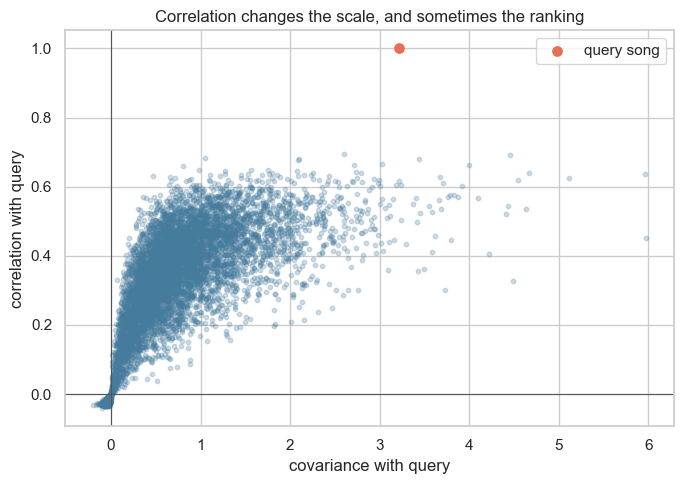

In [46]:
# Visual check: correlation rescales covariance by each song's spread.
plt.figure(figsize=(7, 5))
plt.scatter(covariance_scores, corr_scores, s=10, alpha=0.25, color="#457b9d")
plt.axhline(0, color="#555555", linewidth=0.8)
plt.axvline(0, color="#555555", linewidth=0.8)
plt.scatter(covariance_scores[query_idx], corr_scores[query_idx], color="#e76f51", s=45, label="query song")
plt.xlabel("covariance with query")
plt.ylabel("correlation with query")
plt.title("Correlation changes the scale, and sometimes the ranking")
plt.legend()
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-warning">

Correlation and covariance are related, but not identical. What kind of song might move up in the ranking after standardization? What kind might move down?

Adapt the above code chunks to find the top three **non-self** matches for all of the Top 40 songs by genre using the correlation. Before sorting, set the query song's score to `-np.inf`. Save your results as additional columns in "./data/top_40_songs_by_genre_results.csv".

</div>

A song that shares a similar word pattern could move up in ranking after standardization, while those that may have the same words, but completely differing word patterns, will move down. 

In [ ]:
top1_artist = []
top1_song = []

top2_artist = []
top2_song = []

top3_artist = []
top3_song = []

for track_id in top_40["track_id"]:
    
    query_idx = songs.index[songs["track_id"] == track_id][0]
    
    query = X[query_idx]
    
    query_std = query.std()
    
    query_centered = query - query.mean()
    X_centered = X - X.mean(axis=1, keepdims=True)
    
    centered_dot_scores = X_centered @ query_centered
    covariance_scores = centered_dot_scores / X.shape[1]
    
    denom = X_std * query_std
    
    corr_scores = np.divide(
        covariance_scores,
        denom,
        out=np.zeros_like(covariance_scores),
        where=denom != 0,
    )
    
    corr_scores[query_idx] = -np.inf
    
    top_indices = np.argsort(corr_scores)[-3:][::-1]
    
    top1_artist.append(songs.loc[top_indices[0], "artist_name"])
    top1_song.append(songs.loc[top_indices[0], "song_title"])
    
    top2_artist.append(songs.loc[top_indices[1], "artist_name"])
    top2_song.append(songs.loc[top_indices[1], "song_title"])
    
    top3_artist.append(songs.loc[top_indices[2], "artist_name"])
    top3_song.append(songs.loc[top_indices[2], "song_title"])


results["corr_match_1_artist"] = top1_artist
results["corr_match_1_song"] = top1_song

results["corr_match_2_artist"] = top2_artist
results["corr_match_2_song"] = top2_song

results["corr_match_3_artist"] = top3_artist
results["corr_match_3_song"] = top3_song

results.head()

,track_id,song_id,artist_id,artist_name,song_title,genre,match_1_artist,match_1_song,match_2_artist,match_2_song,...,cov_match_2_artist,cov_match_2_song,cov_match_3_artist,cov_match_3_song,corr_match_1_artist,corr_match_1_song,corr_match_2_artist,corr_match_2_song,corr_match_3_artist,corr_match_3_song
0,TRVYEUW128F148C08D,SOFCCWD12AF72A6BC0,ARXPPEY1187FB51DF4,Michael Jackson,All The Things You Are,blues,Lauryn Hill,Interlude 5,Twista,I'm A Winner (Amended Album Version),...,Twista,I'm A Winner (Amended Album Version),Katy Perry,Hot N Cold (Innerpartysystem Main),Tony Bennett,You're All The World To Me,Patricia Barber,You're The Top,Husker Du,You're A Soldier
1,TRCXKPC128F92FD04C,SOEFNXT12AB017E829,ARZENOX1187B98A645,John Mayer,Vultures,blues,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,Lauryn Hill,Interlude 5,...,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,Eminem,8 Mile,Naked Aggression,Plastic World,Ozma,The Ups And Downs,Sage Francis,Keep Moving
2,TRMMALW128F92FD049,SOVUCRS12A58A7D207,ARZENOX1187B98A645,John Mayer,Out Of My Mind,blues,Lauryn Hill,Interlude 5,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,...,Twista,I'm A Winner (Amended Album Version),Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,Fat Joe,Preacher On A Sunday Morning,Calvin Harris,Ready For The Weekend,KATAKLYSM,Beyond Salvation
3,TRJWAJC128F9327C4F,SORMDVX12AB01816AA,ARLMXEA1187B9A7D04,R. Kelly,Hump Bounce,blues,Lauryn Hill,Interlude 5,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,...,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,Erykah Badu,I Want You,The Derek Trucks Band,All I Do,Avalon,Overjoyed,Billie Piper,Day And Night
4,TRPEBTH128F9327C4D,SOYTJAC12AF729F49D,ARLMXEA1187B9A7D04,R. Kelly,Intro - The Sermon,blues,Lauryn Hill,Interlude 5,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,...,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,Twista,I'm A Winner (Amended Album Version),Blues Traveler,Hook,G-Unit,I Don't Want To Talk About It,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...


In [48]:
results.to_csv("./data/top_40_songs_by_genre_results.csv", index=False)

## Step 4: Cosine Similarity

Cosine similarity compares the raw vectors without centering around their means:

$$
\cos(\theta) = \frac{x \cdot y}{\|x\|\|y\|}
$$

In retrieval systems, this is often a better measure of content similarity than the raw dot product.

In [49]:
def cosine_scores(matrix, query_vector):
    numerators = matrix @ query_vector
    matrix_norms = np.linalg.norm(matrix, axis=1)
    query_norm = np.linalg.norm(query_vector)
    denominators = matrix_norms * query_norm
    return np.divide(
        numerators,
        denominators,
        out=np.zeros_like(numerators),
        where=denominators != 0,
    )


cos_scores = cosine_scores(X, query)

cosine_results = songs[meta_cols].copy()
cosine_results["cosine"] = cos_scores
cosine_results.sort_values("cosine", ascending=False).head(10)

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test,cosine
7795,TRRKJGZ128F148128F,SOAQCXS12D02191FC1,ART1UFU1187FB4C9B6,Hawk Nelson,Something On My Mind,Smile_ It's The End Of The World,2006,259.18649,0.738436,0.621970,rock,cross2life; alternative; favorites; christian;...,345,92,51.913389,0,1.000000
7779,TRQXNHC12903CD80BA,SOFKHCP12A8AE460AF,ARV4GYZ1187B9B8171,Violent Femmes,Add It Up,Permanent Record: The Very Best Of The Violent...,1983,284.34240,0.699073,0.522720,rock,alternative; 80s; rock; punk; indie,479,145,60.745370,0,0.708420
2815,TRISBQQ128F93217A2,SOSKAYL12AB01884DE,ARPXABO1187FB4D15F,2Pac,Strictly 4 My N.I.G.G.A.Z.,Strictly 4 My N.I.G.G.A.Z.,0,355.47383,0.873187,0.517256,hip hop,Hip-Hop; hardcore rap; west coast hip-hop; lea...,921,288,104.316825,0,0.707237
2809,TRILLIR128F429E5D7,SOGGIPC12A8C142CD5,AR6F6I21187FB5A3AA,Aesop Rock,Battery,Labor Days,2001,307.04281,0.834539,0.477311,hip hop,Hip-Hop; underground hip-hop; rap; hip hop; De...,617,294,50.547008,0,0.697772
3129,TRWUNDW128F147093F,SOFZLVC12A6D4F9068,ARNHMFD1187FB3B3F6,LL Cool J,I Can't Live Without My Radio,Radio,1985,331.88526,0.749218,0.544322,hip hop,Hip-Hop; rap; 80s; LL Cool J; hip hop,745,248,81.829090,0,0.696088
7358,TRBCRNY128F931D755,SOZHKRD12AB0185D84,ARKXXO11187FB4D9D9,Bad Cash Quartet,Valentine,Midnight Prayer,2003,175.62077,0.560999,0.399430,rock,indie; swedish; indie pop; indie rock; vocal,157,68,24.879711,0,0.696041
3112,TRWFXWM128F148D2D1,SORSMQE12A58A7A5FE,ARSQSCB1187B9912A0,Warren G,We Brings Heat,Take A Look Over Your Shoulder (Reality),1997,226.92526,0.718017,0.511683,hip hop,chillout; classic; hip hop; cool; Hip-Hop,548,238,50.517324,0,0.694369
3065,TRTMQWK128F4241384,SOIPJHX12A8C1324A3,ARSUQ9F1187B990561,Kottonmouth Kings,Bump,Greatest Highs,1998,232.51546,0.680868,0.563168,hip hop,Hip-Hop; stoned; BUMP; rapcore; kmk,795,259,74.276510,0,0.682323
2841,TRJPNAE128F425FAFB,SOZVCKM12A8C138484,ARRQWQW1187FB49844,King Tee,Act A Fool,Act A Fool,1988,258.82077,0.495739,0.372392,hip hop,Hip-Hop; rap; hip hop; West Coast Rap; west co...,624,251,66.730802,0,0.680961
7974,TRZCHKB128F92CB740,SOFCVMN12A8C141F62,AR4RBOB1187B9AC209,Anastacia,Club Megamix,Pieces Of A Dream,0,708.72771,0.583809,0.323554,rock,Slow Rock; pop; dance; party; female vocalist,749,201,98.020406,0,0.679759


<div class="alert alert-block alert-warning">

Compare the dot-product ranking to the cosine-similarity ranking. Which one seems more like a "similar songs" engine and which one seems more like a "shares lots of raw word mass" engine?

Adapt the above code chunks to find the top three **non-self** matches for all of the Top 40 songs by genre using cosine similarity. Before sorting, set the query song's score to `-np.inf`. Save your results as another column in "./data/top_40_songs_by_genre_results.csv".

</div>

Dot product ranking appears to be more like the "shares lots of raw word mass" engine, as it just matches based off word matches, while the cosine-similarity engine seems to be more like a "similar songs" engine. Cosine engine focuses more on the pattern of word usage rather than just looking at the raw word usage. 

In [ ]:
top1_artist = []
top1_song = []

top2_artist = []
top2_song = []

top3_artist = []
top3_song = []

for track_id in top_40["track_id"]:
    
    query_idx = songs.index[songs["track_id"] == track_id][0]
    
    query = X[query_idx]
    
    cos_scores = cosine_scores(X, query)
    
    cos_scores[query_idx] = -np.inf
    
    top_indices = np.argsort(cos_scores)[-3:][::-1]
    
    top1_artist.append(songs.loc[top_indices[0], "artist_name"])
    top1_song.append(songs.loc[top_indices[0], "song_title"])
    
    top2_artist.append(songs.loc[top_indices[1], "artist_name"])
    top2_song.append(songs.loc[top_indices[1], "song_title"])
    
    top3_artist.append(songs.loc[top_indices[2], "artist_name"])
    top3_song.append(songs.loc[top_indices[2], "song_title"])


results["cos_match_1_artist"] = top1_artist
results["cos_match_1_song"] = top1_song

results["cos_match_2_artist"] = top2_artist
results["cos_match_2_song"] = top2_song

results["cos_match_3_artist"] = top3_artist
results["cos_match_3_song"] = top3_song


,track_id,song_id,artist_id,artist_name,song_title,genre,match_1_artist,match_1_song,match_2_artist,match_2_song,...,corr_match_2_artist,corr_match_2_song,corr_match_3_artist,corr_match_3_song,cos_match_1_artist,cos_match_1_song,cos_match_2_artist,cos_match_2_song,cos_match_3_artist,cos_match_3_song
0,TRVYEUW128F148C08D,SOFCCWD12AF72A6BC0,ARXPPEY1187FB51DF4,Michael Jackson,All The Things You Are,blues,Lauryn Hill,Interlude 5,Twista,I'm A Winner (Amended Album Version),...,Patricia Barber,You're The Top,Husker Du,You're A Soldier,Tony Bennett,You're All The World To Me,Patricia Barber,You're The Top,Husker Du,You're A Soldier
1,TRCXKPC128F92FD04C,SOEFNXT12AB017E829,ARZENOX1187B98A645,John Mayer,Vultures,blues,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,Lauryn Hill,Interlude 5,...,Ozma,The Ups And Downs,Sage Francis,Keep Moving,Naked Aggression,Plastic World,Ozma,The Ups And Downs,Sage Francis,Keep Moving
2,TRMMALW128F92FD049,SOVUCRS12A58A7D207,ARZENOX1187B98A645,John Mayer,Out Of My Mind,blues,Lauryn Hill,Interlude 5,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,...,Calvin Harris,Ready For The Weekend,KATAKLYSM,Beyond Salvation,Fat Joe,Preacher On A Sunday Morning,Calvin Harris,Ready For The Weekend,KATAKLYSM,Beyond Salvation
3,TRJWAJC128F9327C4F,SORMDVX12AB01816AA,ARLMXEA1187B9A7D04,R. Kelly,Hump Bounce,blues,Lauryn Hill,Interlude 5,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,...,Avalon,Overjoyed,Billie Piper,Day And Night,The Derek Trucks Band,All I Do,Avalon,Overjoyed,Billie Piper,Day And Night
4,TRPEBTH128F9327C4D,SOYTJAC12AF729F49D,ARLMXEA1187B9A7D04,R. Kelly,Intro - The Sermon,blues,Lauryn Hill,Interlude 5,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,...,G-Unit,I Don't Want To Talk About It,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,Blues Traveler,Hook,G-Unit,I Don't Want To Talk About It


In [51]:
results.to_csv("./data/top_40_songs_by_genre_results.csv", index=False)

In [53]:
results.head()

,track_id,song_id,artist_id,artist_name,song_title,genre,match_1_artist,match_1_song,match_2_artist,match_2_song,...,corr_match_2_artist,corr_match_2_song,corr_match_3_artist,corr_match_3_song,cos_match_1_artist,cos_match_1_song,cos_match_2_artist,cos_match_2_song,cos_match_3_artist,cos_match_3_song
0,TRVYEUW128F148C08D,SOFCCWD12AF72A6BC0,ARXPPEY1187FB51DF4,Michael Jackson,All The Things You Are,blues,Lauryn Hill,Interlude 5,Twista,I'm A Winner (Amended Album Version),...,Patricia Barber,You're The Top,Husker Du,You're A Soldier,Tony Bennett,You're All The World To Me,Patricia Barber,You're The Top,Husker Du,You're A Soldier
1,TRCXKPC128F92FD04C,SOEFNXT12AB017E829,ARZENOX1187B98A645,John Mayer,Vultures,blues,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,Lauryn Hill,Interlude 5,...,Ozma,The Ups And Downs,Sage Francis,Keep Moving,Naked Aggression,Plastic World,Ozma,The Ups And Downs,Sage Francis,Keep Moving
2,TRMMALW128F92FD049,SOVUCRS12A58A7D207,ARZENOX1187B98A645,John Mayer,Out Of My Mind,blues,Lauryn Hill,Interlude 5,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,...,Calvin Harris,Ready For The Weekend,KATAKLYSM,Beyond Salvation,Fat Joe,Preacher On A Sunday Morning,Calvin Harris,Ready For The Weekend,KATAKLYSM,Beyond Salvation
3,TRJWAJC128F9327C4F,SORMDVX12AB01816AA,ARLMXEA1187B9A7D04,R. Kelly,Hump Bounce,blues,Lauryn Hill,Interlude 5,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,...,Avalon,Overjoyed,Billie Piper,Day And Night,The Derek Trucks Band,All I Do,Avalon,Overjoyed,Billie Piper,Day And Night
4,TRPEBTH128F9327C4D,SOYTJAC12AF729F49D,ARLMXEA1187B9A7D04,R. Kelly,Intro - The Sermon,blues,Lauryn Hill,Interlude 5,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,...,G-Unit,I Don't Want To Talk About It,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,Blues Traveler,Hook,G-Unit,I Don't Want To Talk About It


<div class="alert alert-block alert-warning">

For the Top 40 songs, do you notice any patterns across the inner product, correlation, and cosine similarity top three recommendations you provided? Is there significant agreement, or do the recommendations change significantly by method?

Which methods are most in agreement?

Which methods do you think give the best results?

</div>

Across the Top 40 songs we see that the inner product and covariance methods tend to have the most agreement, often producing the same or very similar top three recommendations. Correlation and cosine similarity also show substantial agreement with each other, and in some cases produce the exact same three recommendations. However, the recommendations can change significantly between these two groups. For example, for All The Things You Are, the inner product and covariance methods recommend Lauryn Hill, Twista, and Katy Perry, while correlation and cosine similarity recommend Tony Bennett, Patricia Barber, and Husker Du. Overall, I think cosine similarity and correlation give the best results for finding similar songs because they normalize the vectors and focus more on the pattern of word usage rather than the total amount of word counts. The inner product seems more likely to favor songs that share a large amount of raw word count. 

## Step 5:

Some words are "outliers": They appear in many songs with overwhelming frequency. For example, "love" is a common word in songs. That will boost the inner product significantly. Conversely, rare words like "amortization" or "zebra" might be rare and important for matching, but receive the same weight as a generic word like "about".

There is a useful technology to deal with this. We're going to cover one way of implementing it.

- Step 1: Compute the **term frequency** of each song-word pair, by taking $\log(1+x_{song,word})$. This is a matrix, $TF$. This transformation reduces the marginal importance of common words.
- Step 2: Compute the **inverse document frequency** of each word. Let $N$ be the number of documents. Let $df_w$ be the document frequency of word $w$, the num of documents in which word $w$ appears. Then $IDF_w = \log( N / df_w)$.

The **TF-IDF** matrix reweights the $TF$ matrix by the $IDF$ vector: $TFIDF = TF 	imes IDF$. This transformed matrix is then used for retrieval calculations (raw inner product, centered inner product, correlation, cosine similarity), instead of the raw word counts.

In [54]:
# Term frequency: repeated uses of one word count less and less.
TF = np.log1p(X) # Compute TF

# Document frequency: how many songs use each word at least once.
N = X.shape[0] # Determine number of documents
df = (X > 0).sum(axis=0) # Compute document frequency
IDF = np.log(N / df) # Compute IDF

# IDF is one number per word, so NumPy broadcasts it across every song row.
TFIDF = TF * IDF

print(pd.DataFrame({
    "word": word_cols,
    "document_frequency": df,
    "idf": IDF,
}).sort_values("idf", ascending=True).head(10))

print( pd.DataFrame({
    "word": word_cols,
    "document_frequency": df,
    "idf": IDF,
}).sort_values("idf", ascending=False).head(10) )

     word  document_frequency       idf
324     i                5966  0.293365
22    and                5960  0.294371
795   you                5671  0.344076
409    me                5420  0.389346
331    in                5345  0.403280
334    is                5191  0.432515
336    it                5045  0.461044
466   not                4961  0.477834
475    of                4785  0.513956
662  that                4597  0.554038
     word  document_frequency       idf
176   doo                  26  5.729100
258  funk                  48  5.115996
726   ven                  56  4.961845
327   ihr                  59  4.909659
770   wir                  60  4.892852
201    er                  63  4.844062
711     u                  66  4.797542
162  dich                  68  4.767689
596   sie                  78  4.630488
208    eu                  81  4.592748


<div class="alert alert-block alert-warning">

Do you notice any patterns among the lowest and highest IDF words?

Rerun your results from the previous steps to use raw inner product, centered inner product, correlation, and cosine similarity to generate new top 3 **non-self** recommendations for the top 40 songs.

How do the new TF-IDF-based recommendations compare to one another and the original recommendations?

</div>

The lowest IDF words are some of the most common words in the English language, like i, and, you, me, etc. The highest IDF words are highly uncommon words, some of which are not even in English and seem to be possibly German. 

In [55]:
tfidf_cos_match_1_artist = []
tfidf_cos_match_1_song = []

tfidf_cos_match_2_artist = []
tfidf_cos_match_2_song = []

tfidf_cos_match_3_artist = []
tfidf_cos_match_3_song = []

for track_id in top_40["track_id"]:
    
    query_idx = songs.index[songs["track_id"] == track_id][0]
    
    query = TFIDF[query_idx]
    
    cos_scores = cosine_scores(TFIDF, query)
    
    cos_scores[query_idx] = -np.inf
    
    top_indices = np.argsort(cos_scores)[-3:][::-1]
    
    tfidf_cos_match_1_artist.append(songs.loc[top_indices[0], "artist_name"])
    tfidf_cos_match_1_song.append(songs.loc[top_indices[0], "song_title"])
    
    tfidf_cos_match_2_artist.append(songs.loc[top_indices[1], "artist_name"])
    tfidf_cos_match_2_song.append(songs.loc[top_indices[1], "song_title"])
    
    tfidf_cos_match_3_artist.append(songs.loc[top_indices[2], "artist_name"])
    tfidf_cos_match_3_song.append(songs.loc[top_indices[2], "song_title"])

results["tfidf_cos_match_1_artist"] = tfidf_cos_match_1_artist
results["tfidf_cos_match_1_song"] = tfidf_cos_match_1_song
results["tfidf_cos_match_2_artist"] = tfidf_cos_match_2_artist
results["tfidf_cos_match_2_song"] = tfidf_cos_match_2_song
results["tfidf_cos_match_3_artist"] = tfidf_cos_match_3_artist
results["tfidf_cos_match_3_song"] = tfidf_cos_match_3_song

results.head()

,track_id,song_id,artist_id,artist_name,song_title,genre,match_1_artist,match_1_song,match_2_artist,match_2_song,...,cos_match_2_artist,cos_match_2_song,cos_match_3_artist,cos_match_3_song,tfidf_cos_match_1_artist,tfidf_cos_match_1_song,tfidf_cos_match_2_artist,tfidf_cos_match_2_song,tfidf_cos_match_3_artist,tfidf_cos_match_3_song
0,TRVYEUW128F148C08D,SOFCCWD12AF72A6BC0,ARXPPEY1187FB51DF4,Michael Jackson,All The Things You Are,blues,Lauryn Hill,Interlude 5,Twista,I'm A Winner (Amended Album Version),...,Patricia Barber,You're The Top,Husker Du,You're A Soldier,Colin James,These Arms Of Mine,Big Bad Voodoo Daddy,Please Baby,Michael Jackson,Baby Be Mine
1,TRCXKPC128F92FD04C,SOEFNXT12AB017E829,ARZENOX1187B98A645,John Mayer,Vultures,blues,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,Lauryn Hill,Interlude 5,...,Ozma,The Ups And Downs,Sage Francis,Keep Moving,Matisyahu,Fire and Heights,Barry White,Never Gonna Give You Up,Matisyahu,Jerusalem
2,TRMMALW128F92FD049,SOVUCRS12A58A7D207,ARZENOX1187B98A645,John Mayer,Out Of My Mind,blues,Lauryn Hill,Interlude 5,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,...,Calvin Harris,Ready For The Weekend,KATAKLYSM,Beyond Salvation,Heatmiser,Half Right,Eminem,If I Had,Gary Allan,Half Of My Mistakes
3,TRJWAJC128F9327C4F,SORMDVX12AB01816AA,ARLMXEA1187B9A7D04,R. Kelly,Hump Bounce,blues,Lauryn Hill,Interlude 5,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,...,Avalon,Overjoyed,Billie Piper,Day And Night,Bowling For Soup,Here We Go,Wade Hayes,Don't Stop,UB40,Here I Am (Come And Take Me)
4,TRPEBTH128F9327C4D,SOYTJAC12AF729F49D,ARLMXEA1187B9A7D04,R. Kelly,Intro - The Sermon,blues,Lauryn Hill,Interlude 5,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,...,Blues Traveler,Hook,G-Unit,I Don't Want To Talk About It,Beastie Boys,Pass The Mic (Pt. 2_ Skills To Pay The Bills) ...,Lauryn Hill,Interlude 5,Jennifer Lopez,The Way It Is


In [56]:
results.to_csv("./data/top_40_songs_by_genre_results.csv", index=False)

The TF-IDF based recommendations changed a lot compared with the original recommendations. The original methods were influenced more by common words, while TF-IDF reduces the importance of words that occur in many songs and increases the importance of rarer words. For example, the original cosine recommendations for Michael Jackson's All The Things You Are were Tony Bennett, Patricia Barber, and Husker Du, while the TF-IDF cosine recommendations were Colin James, Big Bad Voodoo Daddy, and Michael Jackson. Notably, Michael Jackson is being suggested as a recommendation for another Michael Jackson song, suggesting that TF-IDF could be performing better. Overall, the TF-IDF recommendations appear to focus more on specific vocabulary rather than common words, resulting in very different recommendations.

## Part 2: Evaluate a Genre Retrieval System

To engineer a system, we need a ground truth for success or failure. In practice, we would have experts label a dataset or observe user responses and infer success or failure (success might mean they continue their session and click on one of our recommendations, and failure means their session continues but they search for new songs on their own). In the absence of a ground truth, we can use the song genre.

So your job is:

1. For every Top-40 query song, remove the query song itself and every song by the same artist before selecting the top three recommendations for raw inner product, cosine similarity, and TF-IDF-based cosine similarity. If a recommendation's genre matches the query song's genre, record a hit (`True`); otherwise record a miss (`False`). Report `hits.mean()`: this is mean **precision@3**, the share of all recommendation slots that are same-genre hits. Do not hard-code the denominator.
2. Using the ideas from step 1, try to engineer a system that outperforms the available baselines. What matters is your explanation for why you designed the system you did, not whether or not it outperforms the baselines.
3. Write up your results in a separate text file, as a report on your work as a data engineer. Do the existing options work well, or did you find ways to outperform it?


In [58]:
def evaluate_recommendations(matrix, score_function):
    
    hits = []

    for track_id in top_40["track_id"]:

        query_idx = songs.index[songs["track_id"] == track_id][0]
        query = matrix[query_idx]

        scores = score_function(matrix, query)

        query_artist = songs.loc[query_idx, "artist_name"]

        same_artist = songs["artist_name"] == query_artist
        scores[same_artist.to_numpy()] = -np.inf

        top_indices = np.argsort(scores)[-3:][::-1]

        query_genre = top_40.loc[top_40["track_id"] == track_id, "genre"].iloc[0]

        for idx in top_indices:
            recommendation_genre = songs.loc[idx, "genre"]
            hits.append(recommendation_genre == query_genre)

    return np.array(hits)

In [60]:
def raw_inner_product(matrix, query):
    return matrix @ query

raw_hits = evaluate_recommendations(X, raw_inner_product)
raw_precision = raw_hits.mean()
print(raw_precision)

0.09285714285714286


In [61]:
# Reusing cosine evaluation function from earlier, but putting it here so I can see it again in the pipeline

def cosine_scores(matrix, query_vector):
    numerators = matrix @ query_vector
    matrix_norms = np.linalg.norm(matrix, axis=1)
    query_norm = np.linalg.norm(query_vector)
    denominators = matrix_norms * query_norm
    return np.divide(
        numerators,
        denominators,
        out=np.zeros_like(numerators),
        where=denominators != 0,
    )

cosine_hits = evaluate_recommendations(X, cosine_scores)
cosine_precision = cosine_hits.mean()
print(cosine_precision)

0.19107142857142856


In [62]:
tfidf_cosine_hits = evaluate_recommendations(TFIDF, cosine_scores)

tfidf_cosine_precision = tfidf_cosine_hits.mean()
print(tfidf_cosine_precision)

0.21071428571428572


In [63]:
baseline_results = pd.DataFrame({
    "method": [
        "Dot product",
        "Cosine similarity",
        "TF-IDF cosine similarity"
    ],
    "precision_at_3": [
        raw_precision,
        cosine_precision,
        tfidf_cosine_precision
    ]
})

baseline_results

,method,precision_at_3
0,Dot product,0.092857
1,Cosine similarity,0.191071
2,TF-IDF cosine similarity,0.210714


I asked ChatGPT for an idea that could generate a higher precision score, it suggested using TF-IDF to get an initial group of candidates that will be similar, then to rank them uing cosine similarity, as it could help refine down the more specific genre of music to recommend. The goal was to hopefully use the strengths of TF-IDF to get a good initial group, and then have cosine similarity find a song with the same genre based off the words.

In [67]:
hits = []

for track_id in top_40["track_id"]:

    query_idx = songs.index[songs["track_id"] == track_id][0]

    # Start with TF-IDF cosine to find options
    tfidf_query = TFIDF[query_idx]
    tfidf_scores = cosine_scores(TFIDF, tfidf_query)

    query_artist = songs.loc[query_idx, "artist_name"]
    same_artist = songs["artist_name"] == query_artist
    tfidf_scores[same_artist.to_numpy()] = -np.inf

    # Get top 20 possible candidates
    candidate_indices = np.argsort(tfidf_scores)[-20:][::-1]


    # Score the top 20 candidates using cosine similarity
    candidate_scores = cosine_scores(X[candidate_indices], X[query_idx])

    top_3_positions = np.argsort(candidate_scores)[-3:][::-1]
    top_indices = candidate_indices[top_3_positions]

    query_genre = top_40.loc[top_40["track_id"] == track_id, "genre"].iloc[0]

    for idx in top_indices:
        recommendation_genre = songs.loc[idx, "genre"]
        hits.append(recommendation_genre == query_genre)

reranking_hits = np.array(hits)
reranking_precision = reranking_hits.mean()

print("TF-IDF cosine:", tfidf_cosine_precision)
print("TF-IDF with cosine similarity after:", reranking_precision)

TF-IDF cosine: 0.21071428571428572
TF-IDF with cosine similarity after: 0.21428571428571427
